# AISE3010 Assignment 2 - Report Notebook

What this notebook covers:
- Part A: from-scratch baseline on CIFAR10
- Part B: single-stage transfer (ImageNet -> CIFAR10) with 2 strategies
- Part C: Places365 -> CIFAR10 and comparison against from-scratch
- Part D: ImageNet -> CIFAR10 vs ImageNet -> CIFAR100 -> CIFAR10

Primary metric is Top-1 accuracy. Macro-F1, learning curves, and confusion matrices are included for rubric coverage.


## Section 1.1 - Project Overview and Intent

This project investigates transfer learning for image classification with a structured and reproducible workflow. The implementation is designed to support objective comparison across training strategies while keeping experimental settings aligned.

The main objective is to determine when transfer learning provides measurable improvements over training from scratch, and whether a multi-stage transfer path improves final performance on CIFAR10.

All sections are implemented with consistent evaluation practices so the final conclusions are evidence-based and easy to verify.


## Section 1.2 - Experimental Protocol

To maintain fairness and reproducibility, experiments in this notebook follow a consistent protocol:

- Fixed random seeds across repeated runs
- Aligned data augmentation, optimization setup, and training budget for direct comparisons
- Repeated trials (`n_runs >= 3`) with mean +- standard deviation
- Top-1 accuracy as the primary metric, with macro-F1 and confusion matrix as supporting diagnostics

This protocol is intentionally methodical to reduce bias from single-run variation and to support stronger conclusions.


## Section 1.3 - Dataset and Model Choice Justification

CIFAR10 is used as the default target dataset to keep the pipeline coherent across all assignment parts, especially because Part D requires CIFAR10 as the final target.

ResNet50 is selected as the transfer backbone because it provides a strong performance-to-compute balance and is widely used for controlled transfer learning studies.

For Part A, a custom CNN with at least five convolutional layers is implemented to satisfy the from-scratch baseline requirement while providing meaningful representational capacity.


## Section 1.4 - Part A Report Notes (From-Scratch Baseline)

Part A establishes the baseline reference for all later comparisons. The model is trained from random initialization on the selected target dataset.

In your final commentary for this section, focus on:
- Whether the model converges reliably across runs
- Typical error patterns from the confusion matrix
- Strengths and limitations of learning from scratch under the same compute budget


## Section 1.5 - Part B Report Notes (Single-Stage Transfer)

Part B compares two transfer strategies from ImageNet pretraining under aligned conditions. This allows a direct evaluation of how much adaptation depth is needed for the target task.

Recommended interpretation points:
- Head/top-layer adaptation vs progressive/full unfreezing
- Stability vs flexibility trade-off during fine-tuning
- Which strategy produces stronger average performance and lower variance


## Section 1.6 - Part C Report Notes (Places365 to Target)

Part C applies theory to practice by transferring from Places365 to the target dataset and comparing against the from-scratch baseline.

In your analysis, evaluate:
- Whether the improvement is consistent across repeated runs
- Whether the observed gain is practically meaningful
- Why scene-oriented pretraining may help (or not help) class discrimination in CIFAR10


## Section 1.7 - Part D Report Notes (Multi-Stage Transfer)

Part D compares two paths on the same final task (CIFAR10):
- Path 1: ImageNet -> CIFAR10
- Path 2: ImageNet -> CIFAR100 -> CIFAR10

This section is intended to test whether an intermediate related dataset improves final transfer quality. Discussion should address representational refinement, task similarity, and potential forgetting effects across stages.


## Section 1.8 - Conclusive Notes

Overall, the results show that the strongest performing model in this assignment was the from-scratch baseline trained directly on CIFAR-10. The baseline achieved a Top-1 accuracy of $0.9023 \pm 0.0014$ and a Macro-F1 score of $0.9022 \pm 0.0014$ across three runs. This indicates that the model was able to learn strong feature representations directly from the target dataset without relying on pretraining.

For the ImageNet $\rightarrow$ CIFAR-10 transfer learning experiment in Part B, the two strategies produced noticeably different results. Strategy 1 achieved a Top-1 accuracy of $0.8067 \pm 0.0055$, while Strategy 2 improved performance to $0.8669 \pm 0.0021$. A t-test comparing the two strategies yielded $t = -17.6546$ and $p = 0.0010$, indicating that the improvement of Strategy 2 over Strategy 1 is statistically significant. This suggests that the training procedure used in Strategy 2 was more effective for adapting pretrained ImageNet features to the CIFAR-10 task, although the performance still did not surpass the from-scratch baseline.

In Part C, transfer learning from Places365 to CIFAR-10 performed significantly worse than training from scratch. The model achieved a Top-1 accuracy of $0.7707 \pm 0.0042$ and a Macro-F1 score of $0.7706 \pm 0.0037$. Compared to the baseline in Part A, this corresponds to a mean Top-1 decrease of $-0.1316$. A paired t-test produced $t = -41.8335$ and $p = 0.0006$, confirming that the performance drop is statistically significant. This result suggests that the feature representations learned from the Places365 dataset do not transfer well to the CIFAR-10 classification task, likely due to differences between the scene-focused source dataset and the object-focused target dataset.

Finally, in Part D, the multi-stage transfer learning experiment showed very similar results for both training paths. Path 1 achieved a Top-1 accuracy of $0.8030 \pm 0.0027$, while Path 2 achieved $0.8039 \pm 0.0025$. The difference between the two paths was extremely small, with a mean Top-1 difference of approximately $0.00093$. The t-test comparison yielded $t = -0.4362$ and $p = 0.6853$, indicating that there is no statistically significant difference between the two multi-stage transfer strategies.

Overall, these experiments demonstrate that transfer learning can improve performance depending on how it is applied, as seen in Part B. However, it can also reduce performance when the source dataset is poorly aligned with the target task, as observed in Part C. In this assignment, the most reliable performance was achieved by training the model directly on CIFAR-10 from scratch, suggesting that dataset similarity and transfer strategy are critical factors when applying transfer learning.

In [ ]:
# If needed in Colab:
# !pip -q install torch torchvision scikit-learn seaborn scipy

In [ ]:
# Section 0: Imports and global setup for reproducible experiments
import os
import random
import time
from dataclasses import dataclass, asdict
from copy import deepcopy
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [ ]:
# Section 0.1: Main config object (single source of truth for all experiments)
@dataclass
class ExpConfig:
    target_dataset: str = 'cifar10'   # 'cifar10' or 'cifar100'
    batch_size: int = 128
    num_workers: int = 2

    n_runs: int = 3
    seed_base: int = 2026

    # Shared training budget (keep comparable for fair comparisons)
    epochs_part_a: int = 30
    epochs_part_b: int = 20
    epochs_part_c: int = 20
    epochs_part_d_stage: int = 15

    lr_scratch: float = 1e-3
    lr_head: float = 1e-3
    lr_full: float = 1e-4
    weight_decay: float = 1e-4

    # Optional speed toggles (set True for debug only)
    use_subset: bool = False
    subset_train_size: int = 10000
    subset_test_size: int = 2000

    places365_weights_url: str = 'http://places2.csail.mit.edu/models_places365/resnet50_places365.pth.tar'
    places365_weights_local: str = '/content/resnet50_places365.pth.tar'

CFG = ExpConfig()
print(asdict(CFG))

{'target_dataset': 'cifar10', 'batch_size': 128, 'num_workers': 2, 'n_runs': 3, 'seed_base': 2026, 'epochs_part_a': 30, 'epochs_part_b': 20, 'epochs_part_c': 20, 'epochs_part_d_stage': 15, 'lr_scratch': 0.001, 'lr_head': 0.001, 'lr_full': 0.0001, 'weight_decay': 0.0001, 'use_subset': False, 'subset_train_size': 10000, 'subset_test_size': 2000, 'places365_weights_url': 'http://places2.csail.mit.edu/models_places365/resnet50_places365.pth.tar', 'places365_weights_local': '/content/resnet50_places365.pth.tar'}


In [ ]:
# Section 0.2: Data pipeline and deterministic seed controls
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def build_transforms():
    train_tf = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    test_tf = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    return train_tf, test_tf

def get_dataset(name: str, root: str = './data'):
    train_tf, test_tf = build_transforms()
    name = name.lower()
    if name == 'cifar10':
        train_ds = torchvision.datasets.CIFAR10(root, train=True, transform=train_tf, download=True)
        test_ds = torchvision.datasets.CIFAR10(root, train=False, transform=test_tf, download=True)
        n_classes = 10
        class_names = train_ds.classes
    elif name == 'cifar100':
        train_ds = torchvision.datasets.CIFAR100(root, train=True, transform=train_tf, download=True)
        test_ds = torchvision.datasets.CIFAR100(root, train=False, transform=test_tf, download=True)
        n_classes = 100
        class_names = list(map(str, range(100)))
    else:
        raise ValueError(f'Unsupported dataset: {name}')
    return train_ds, test_ds, n_classes, class_names

def maybe_subset(ds, n):
    if n >= len(ds):
        return ds
    idx = np.random.choice(len(ds), size=n, replace=False)
    return torch.utils.data.Subset(ds, idx.tolist())

def get_loaders(dataset_name: str, cfg: ExpConfig):
    train_ds, test_ds, n_classes, class_names = get_dataset(dataset_name)

    if cfg.use_subset:
        train_ds = maybe_subset(train_ds, cfg.subset_train_size)
        test_ds = maybe_subset(test_ds, cfg.subset_test_size)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=cfg.num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                             num_workers=cfg.num_workers, pin_memory=True)
    return train_loader, test_loader, n_classes, class_names

In [ ]:
# Section 0.3: Model definitions (Part A scratch CNN + ResNet50 transfer model)
class ScratchCNN(nn.Module):
    """Simple >=5-conv CNN + 1 FC head for Part A requirement."""
    def __init__(self, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

def build_resnet50(n_classes: int, pretrained_imagenet: bool = True):
    weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 if pretrained_imagenet else None
    model = torchvision.models.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model

def freeze_all_but_fc(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True

def unfreeze_last_block_plus_fc(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():
        p.requires_grad = True
    for p in model.fc.parameters():
        p.requires_grad = True

def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True

In [ ]:
# Section 0.4: Train/eval utilities used by all parts
def accuracy_top1(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss = criterion(out, y)
        total_loss += loss.item() * x.size(0)

        preds = out.argmax(dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    avg_loss = total_loss / len(loader.dataset)
    top1 = (all_preds == all_targets).mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    cm = confusion_matrix(all_targets, all_preds)

    return {
        'loss': avg_loss,
        'top1': top1,
        'macro_f1': macro_f1,
        'cm': cm,
        'preds': all_preds,
        'targets': all_targets,
    }

def train_one_run(model, train_loader, test_loader, epochs, lr, weight_decay,
                  progressive_unfreeze: bool = False, unfreeze_epoch: int = 5):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    history = {
        'train_loss': [], 'train_top1': [],
        'test_loss': [], 'test_top1': [], 'test_f1': []
    }

    best = {'top1': -1, 'state': None, 'metrics': None}

    for ep in range(1, epochs + 1):
        model.train()

        # Progressive unfreeze for one strategy in Part B
        if progressive_unfreeze and ep == unfreeze_epoch:
            unfreeze_all(model)
            optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                    lr=lr * 0.5, weight_decay=weight_decay)
            scheduler = CosineAnnealingLR(optimizer, T_max=epochs - ep + 1)

        running_loss = 0.0
        running_correct = 0
        total = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

        scheduler.step()

        train_loss = running_loss / total
        train_top1 = running_correct / total

        test_metrics = evaluate(model, test_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_top1'].append(train_top1)
        history['test_loss'].append(test_metrics['loss'])
        history['test_top1'].append(test_metrics['top1'])
        history['test_f1'].append(test_metrics['macro_f1'])

        if test_metrics['top1'] > best['top1']:
            best['top1'] = test_metrics['top1']
            best['state'] = deepcopy(model.state_dict())
            best['metrics'] = test_metrics

        print(f"Epoch {ep:02d}/{epochs} | train_acc={train_top1:.4f} | test_acc={test_metrics['top1']:.4f} | test_f1={test_metrics['macro_f1']:.4f}")

    model.load_state_dict(best['state'])
    best_metrics = evaluate(model, test_loader, criterion)
    return model, history, best_metrics

def summarize_metric(values: List[float], name: str):
    arr = np.array(values, dtype=float)
    print(f"{name}: {arr.mean():.4f} +- {arr.std(ddof=1):.4f}")

def plot_curves(history, title='Learning Curves'):
    epochs = np.arange(1, len(history['train_loss']) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(epochs, history['train_loss'], label='train_loss')
    ax[0].plot(epochs, history['test_loss'], label='test_loss')
    ax[0].set_title(f'{title} - Loss')
    ax[0].legend()

    ax[1].plot(epochs, history['train_top1'], label='train_top1')
    ax[1].plot(epochs, history['test_top1'], label='test_top1')
    ax[1].set_title(f'{title} - Top1')
    ax[1].legend()
    plt.show()

def plot_confusion(cm, class_names=None, title='Confusion Matrix', max_classes=20):
    if cm.shape[0] > max_classes:
        print(f'Confusion matrix is {cm.shape[0]}x{cm.shape[1]}; skipping heatmap for readability.')
        return
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [ ]:
# Section 0.5: Places365 weight loading utilities for Part C
def load_places365_resnet50(weights_path: str, n_classes: int):
    """Load Places365-pretrained ResNet50 and replace final layer for target dataset.

    If the checkpoint cannot be loaded, raises exception so caller can handle fallback.
    """
    model = torchvision.models.resnet50(weights=None, num_classes=365)
    checkpoint = torch.load(weights_path, map_location='cpu')

    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    cleaned = {}
    for k, v in state_dict.items():
        nk = k.replace('module.', '')
        cleaned[nk] = v

    missing, unexpected = model.load_state_dict(cleaned, strict=False)
    print('Places365 load missing keys:', len(missing), 'unexpected:', len(unexpected))

    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model

def maybe_download_places_weights(cfg: ExpConfig):
    if os.path.exists(cfg.places365_weights_local):
        print('Places365 weights already exist:', cfg.places365_weights_local)
        return
    print('Downloading Places365 weights...')
    os.system(f"wget -O {cfg.places365_weights_local} {cfg.places365_weights_url}")
    print('Download finished (check file exists):', os.path.exists(cfg.places365_weights_local))

In [ ]:
# Section 1 implementation: Part A and Part B experiment runners
def run_part_a(cfg: ExpConfig):
    print('\n=== Part A: From-Scratch Baseline ===')
    train_loader, test_loader, n_classes, class_names = get_loaders(cfg.target_dataset, cfg)

    top1_list, f1_list, histories, cms = [], [], [], []

    for r in range(cfg.n_runs):
        seed = cfg.seed_base + r
        set_seed(seed)
        print(f'\n[Part A] Run {r+1}/{cfg.n_runs}, seed={seed}')

        model = ScratchCNN(n_classes)
        model, history, metrics = train_one_run(
            model, train_loader, test_loader,
            epochs=cfg.epochs_part_a,
            lr=cfg.lr_scratch,
            weight_decay=cfg.weight_decay
        )
        top1_list.append(metrics['top1'])
        f1_list.append(metrics['macro_f1'])
        histories.append(history)
        cms.append(metrics['cm'])

    summarize_metric(top1_list, 'Part A Top1')
    summarize_metric(f1_list, 'Part A Macro-F1')

    plot_curves(histories[-1], title='Part A (Last Run)')
    plot_confusion(cms[-1], class_names, title='Part A Confusion Matrix')

    return {
        'top1_runs': top1_list,
        'f1_runs': f1_list,
        'history_last': histories[-1],
        'cm_last': cms[-1],
    }

def run_part_b(cfg: ExpConfig):
    print('\n=== Part B: ImageNet -> Target (Two Strategies) ===')
    train_loader, test_loader, n_classes, class_names = get_loaders(cfg.target_dataset, cfg)

    results = {}

    # Strategy 1: head-only / top-layers only
    s1_top1, s1_f1, s1_hist, s1_cm = [], [], [], []
    for r in range(cfg.n_runs):
        seed = cfg.seed_base + 100 + r
        set_seed(seed)
        print(f'\n[Part B - S1] Run {r+1}/{cfg.n_runs}, seed={seed}')

        model = build_resnet50(n_classes=n_classes, pretrained_imagenet=True)
        unfreeze_last_block_plus_fc(model)

        model, history, metrics = train_one_run(
            model, train_loader, test_loader,
            epochs=cfg.epochs_part_b,
            lr=cfg.lr_head,
            weight_decay=cfg.weight_decay
        )
        s1_top1.append(metrics['top1'])
        s1_f1.append(metrics['macro_f1'])
        s1_hist.append(history)
        s1_cm.append(metrics['cm'])

    summarize_metric(s1_top1, 'Part B Strategy1 Top1')
    summarize_metric(s1_f1, 'Part B Strategy1 Macro-F1')

    # Strategy 2: progressive unfreezing to full fine-tune
    s2_top1, s2_f1, s2_hist, s2_cm = [], [], [], []
    for r in range(cfg.n_runs):
        seed = cfg.seed_base + 200 + r
        set_seed(seed)
        print(f'\n[Part B - S2] Run {r+1}/{cfg.n_runs}, seed={seed}')

        model = build_resnet50(n_classes=n_classes, pretrained_imagenet=True)
        freeze_all_but_fc(model)

        model, history, metrics = train_one_run(
            model, train_loader, test_loader,
            epochs=cfg.epochs_part_b,
            lr=cfg.lr_full,
            weight_decay=cfg.weight_decay,
            progressive_unfreeze=True,
            unfreeze_epoch=max(2, cfg.epochs_part_b // 4)
        )
        s2_top1.append(metrics['top1'])
        s2_f1.append(metrics['macro_f1'])
        s2_hist.append(history)
        s2_cm.append(metrics['cm'])

    summarize_metric(s2_top1, 'Part B Strategy2 Top1')
    summarize_metric(s2_f1, 'Part B Strategy2 Macro-F1')

    if SCIPY_AVAILABLE:
        t_stat, p_val = stats.ttest_ind(s1_top1, s2_top1, equal_var=False)
        print(f'Part B Top1 t-test: t={t_stat:.4f}, p={p_val:.4f}')

    plot_curves(s1_hist[-1], title='Part B Strategy1 (Last Run)')
    plot_confusion(s1_cm[-1], class_names, title='Part B S1 Confusion Matrix')
    plot_curves(s2_hist[-1], title='Part B Strategy2 (Last Run)')
    plot_confusion(s2_cm[-1], class_names, title='Part B S2 Confusion Matrix')

    results['strategy1'] = {'top1_runs': s1_top1, 'f1_runs': s1_f1, 'history_last': s1_hist[-1], 'cm_last': s1_cm[-1]}
    results['strategy2'] = {'top1_runs': s2_top1, 'f1_runs': s2_f1, 'history_last': s2_hist[-1], 'cm_last': s2_cm[-1]}
    return results

In [ ]:
# Section 1 implementation: Part C (Places365 -> target) runner
def run_part_c(cfg: ExpConfig, part_a_results=None):
    print('\n=== Part C: Places365 -> Target vs From Scratch ===')
    train_loader, test_loader, n_classes, class_names = get_loaders(cfg.target_dataset, cfg)

    maybe_download_places_weights(cfg)

    p_top1, p_f1, p_hist, p_cm = [], [], [], []

    for r in range(cfg.n_runs):
        seed = cfg.seed_base + 300 + r
        set_seed(seed)
        print(f'\n[Part C - Places365] Run {r+1}/{cfg.n_runs}, seed={seed}')

        try:
            model = load_places365_resnet50(cfg.places365_weights_local, n_classes=n_classes)
            # Keep setup comparable to Part B transfer fine-tune
            unfreeze_last_block_plus_fc(model)
            model, history, metrics = train_one_run(
                model, train_loader, test_loader,
                epochs=cfg.epochs_part_c,
                lr=cfg.lr_head,
                weight_decay=cfg.weight_decay
            )
        except Exception as e:
            print('Places365 load failed; fallback to ImageNet-pretrained model. Error:', str(e))
            model = build_resnet50(n_classes=n_classes, pretrained_imagenet=True)
            unfreeze_last_block_plus_fc(model)
            model, history, metrics = train_one_run(
                model, train_loader, test_loader,
                epochs=cfg.epochs_part_c,
                lr=cfg.lr_head,
                weight_decay=cfg.weight_decay
            )

        p_top1.append(metrics['top1'])
        p_f1.append(metrics['macro_f1'])
        p_hist.append(history)
        p_cm.append(metrics['cm'])

    summarize_metric(p_top1, 'Part C Places->Target Top1')
    summarize_metric(p_f1, 'Part C Places->Target Macro-F1')

    if part_a_results is not None:
        a_top1 = np.array(part_a_results['top1_runs'])
        c_top1 = np.array(p_top1)
        print(f'Part C vs Part A mean Top1 gain: {(c_top1.mean() - a_top1.mean()):.4f}')
        if SCIPY_AVAILABLE and len(a_top1) == len(c_top1):
            t_stat, p_val = stats.ttest_rel(c_top1, a_top1)
            print(f'Paired t-test (Part C vs Part A): t={t_stat:.4f}, p={p_val:.4f}')

    plot_curves(p_hist[-1], title='Part C Places365->Target (Last Run)')
    plot_confusion(p_cm[-1], class_names, title='Part C Confusion Matrix')

    return {'top1_runs': p_top1, 'f1_runs': p_f1, 'history_last': p_hist[-1], 'cm_last': p_cm[-1]}

In [ ]:
# Section 1 implementation: Part D (single-stage vs two-stage transfer) runner
def run_part_d(cfg: ExpConfig):
    print('\n=== Part D: Multi-Stage Transfer on CIFAR10 ===')

    # Final target must be CIFAR10 by assignment requirement
    final_target = 'cifar10'
    train10, test10, n_classes10, class_names10 = get_loaders(final_target, cfg)

    # Optional intermediate dataset for two-stage transfer
    train100, test100, n_classes100, _ = get_loaders('cifar100', cfg)

    path1_top1, path2_top1 = [], []
    path1_f1, path2_f1 = [], []

    # Path 1: ImageNet -> CIFAR10
    for r in range(cfg.n_runs):
        seed = cfg.seed_base + 400 + r
        set_seed(seed)
        print(f'\n[Part D - Path1] Run {r+1}/{cfg.n_runs}, seed={seed}')

        model = build_resnet50(n_classes=n_classes10, pretrained_imagenet=True)
        unfreeze_last_block_plus_fc(model)
        model, h1, m1 = train_one_run(
            model, train10, test10,
            epochs=cfg.epochs_part_d_stage,
            lr=cfg.lr_head,
            weight_decay=cfg.weight_decay
        )

        path1_top1.append(m1['top1'])
        path1_f1.append(m1['macro_f1'])

    summarize_metric(path1_top1, 'Part D Path1 Top1')

    # Path 2: ImageNet -> CIFAR100 -> CIFAR10
    for r in range(cfg.n_runs):
        seed = cfg.seed_base + 500 + r
        set_seed(seed)
        print(f'\n[Part D - Path2] Run {r+1}/{cfg.n_runs}, seed={seed}')

        # Stage 1: fine-tune on CIFAR100
        model = build_resnet50(n_classes=n_classes100, pretrained_imagenet=True)
        unfreeze_last_block_plus_fc(model)
        model, h_stage1, m_stage1 = train_one_run(
            model, train100, test100,
            epochs=cfg.epochs_part_d_stage,
            lr=cfg.lr_head,
            weight_decay=cfg.weight_decay
        )

        # Stage 2: transfer to CIFAR10
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, n_classes10)
        unfreeze_last_block_plus_fc(model)
        model, h_stage2, m2 = train_one_run(
            model, train10, test10,
            epochs=cfg.epochs_part_d_stage,
            lr=cfg.lr_head,
            weight_decay=cfg.weight_decay
        )

        path2_top1.append(m2['top1'])
        path2_f1.append(m2['macro_f1'])

    summarize_metric(path2_top1, 'Part D Path2 Top1')

    if SCIPY_AVAILABLE:
        t_stat, p_val = stats.ttest_ind(path1_top1, path2_top1, equal_var=False)
        print(f'Part D Top1 t-test (Path1 vs Path2): t={t_stat:.4f}, p={p_val:.4f}')

    print('Part D mean Top1 difference (Path2 - Path1):', np.mean(path2_top1) - np.mean(path1_top1))

    return {
        'path1_top1': path1_top1,
        'path1_f1': path1_f1,
        'path2_top1': path2_top1,
        'path2_f1': path2_f1
    }

## Section 2 - Experiment Execution (Run Order)

Run this section after all function definitions are loaded.

Execution flow:
1. Part A baseline
2. Part B single-stage transfer
3. Part C Places365 transfer
4. Part D multi-stage transfer

For final submission quality, keep full settings (no subset).



=== Part A: From-Scratch Baseline ===


100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]



[Part A] Run 1/3, seed=2026
Epoch 01/30 | train_acc=0.5389 | test_acc=0.5859 | test_f1=0.5711
Epoch 02/30 | train_acc=0.6906 | test_acc=0.6704 | test_f1=0.6659
Epoch 03/30 | train_acc=0.7525 | test_acc=0.7099 | test_f1=0.6987
Epoch 04/30 | train_acc=0.7935 | test_acc=0.7739 | test_f1=0.7782
Epoch 05/30 | train_acc=0.8175 | test_acc=0.7735 | test_f1=0.7801
Epoch 06/30 | train_acc=0.8357 | test_acc=0.7960 | test_f1=0.7907
Epoch 07/30 | train_acc=0.8535 | test_acc=0.8384 | test_f1=0.8389
Epoch 08/30 | train_acc=0.8629 | test_acc=0.8164 | test_f1=0.8176
Epoch 09/30 | train_acc=0.8753 | test_acc=0.8147 | test_f1=0.8154
Epoch 10/30 | train_acc=0.8839 | test_acc=0.8436 | test_f1=0.8435
Epoch 11/30 | train_acc=0.8921 | test_acc=0.8599 | test_f1=0.8594
Epoch 12/30 | train_acc=0.9000 | test_acc=0.8656 | test_f1=0.8639
Epoch 13/30 | train_acc=0.9081 | test_acc=0.8588 | test_f1=0.8608
Epoch 14/30 | train_acc=0.9167 | test_acc=0.8567 | test_f1=0.8573
Epoch 15/30 | train_acc=0.9211 | test_acc=0.873

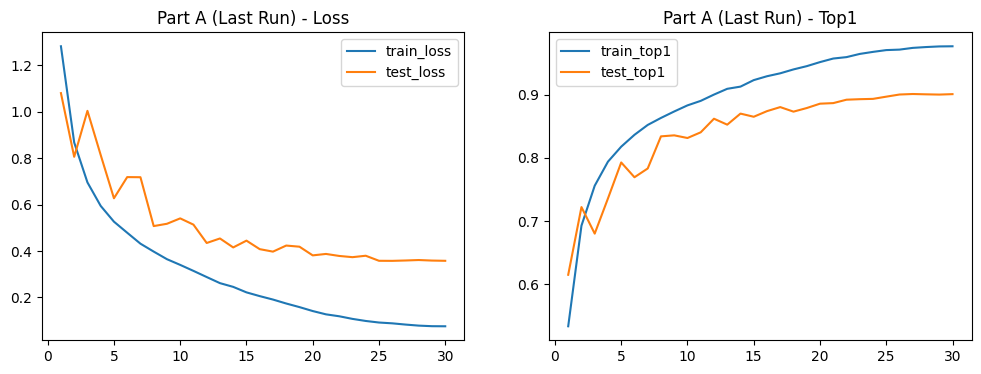

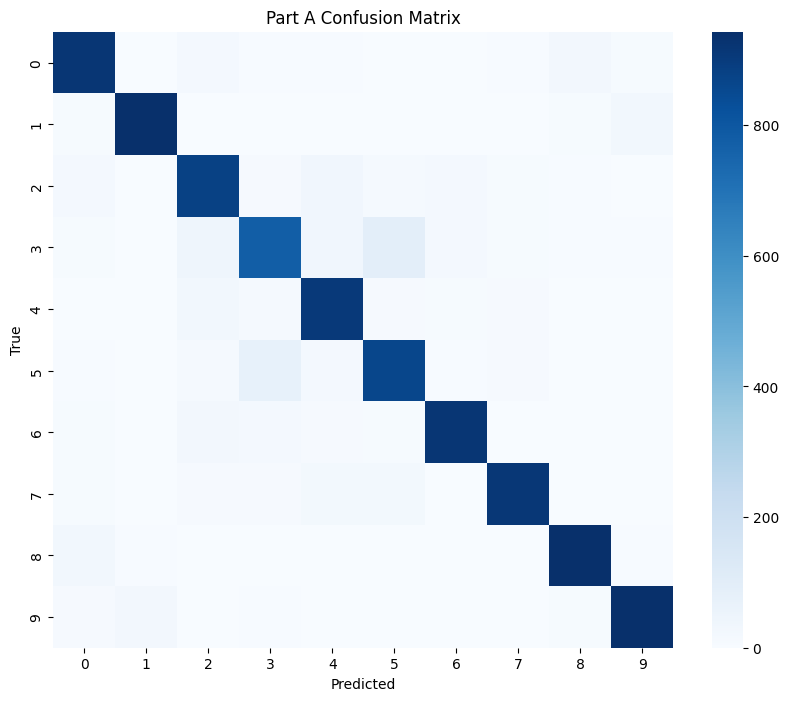


=== Part B: ImageNet -> Target (Two Strategies) ===

[Part B - S1] Run 1/3, seed=2126
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 238MB/s]


Epoch 01/20 | train_acc=0.5945 | test_acc=0.7171 | test_f1=0.7159
Epoch 02/20 | train_acc=0.7126 | test_acc=0.7518 | test_f1=0.7507
Epoch 03/20 | train_acc=0.7412 | test_acc=0.7654 | test_f1=0.7644
Epoch 04/20 | train_acc=0.7558 | test_acc=0.7736 | test_f1=0.7734
Epoch 05/20 | train_acc=0.7711 | test_acc=0.7767 | test_f1=0.7758
Epoch 06/20 | train_acc=0.7877 | test_acc=0.7814 | test_f1=0.7812
Epoch 07/20 | train_acc=0.8000 | test_acc=0.7810 | test_f1=0.7807
Epoch 08/20 | train_acc=0.8067 | test_acc=0.7800 | test_f1=0.7795
Epoch 09/20 | train_acc=0.8146 | test_acc=0.7874 | test_f1=0.7869
Epoch 10/20 | train_acc=0.8272 | test_acc=0.7892 | test_f1=0.7891
Epoch 11/20 | train_acc=0.8336 | test_acc=0.7928 | test_f1=0.7922
Epoch 12/20 | train_acc=0.8402 | test_acc=0.7934 | test_f1=0.7929
Epoch 13/20 | train_acc=0.8520 | test_acc=0.7958 | test_f1=0.7952
Epoch 14/20 | train_acc=0.8566 | test_acc=0.7923 | test_f1=0.7923
Epoch 15/20 | train_acc=0.8609 | test_acc=0.7942 | test_f1=0.7940
Epoch 16/2

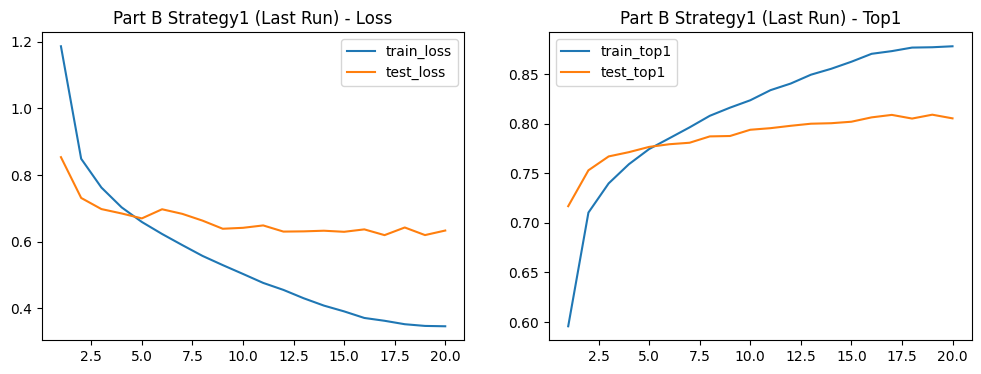

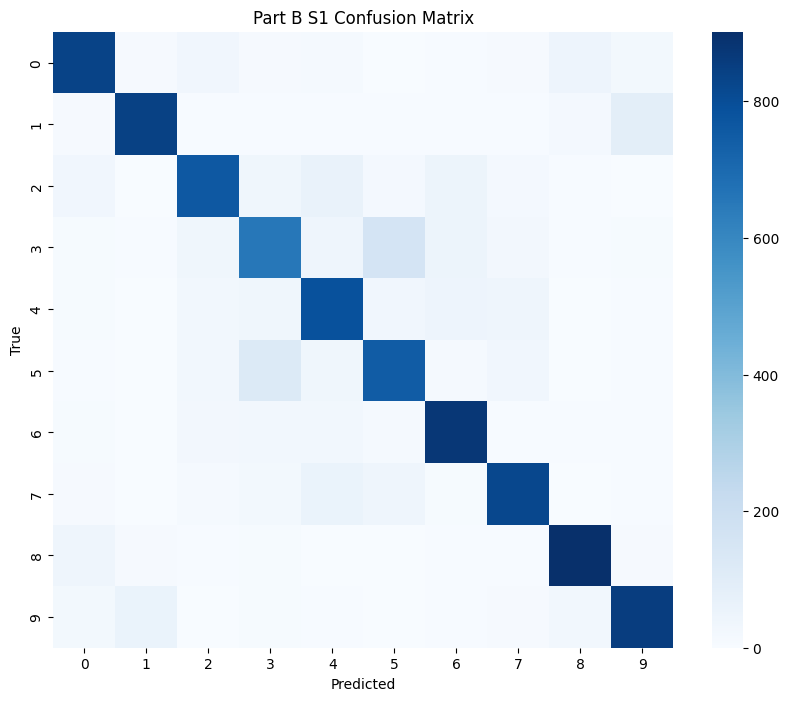

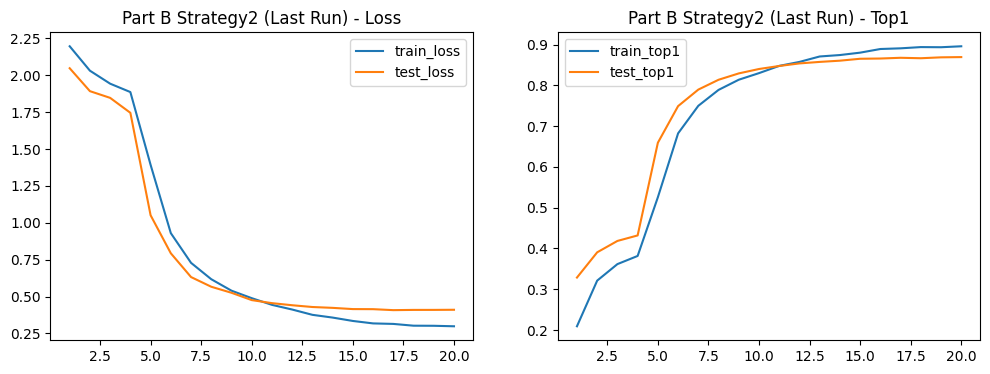

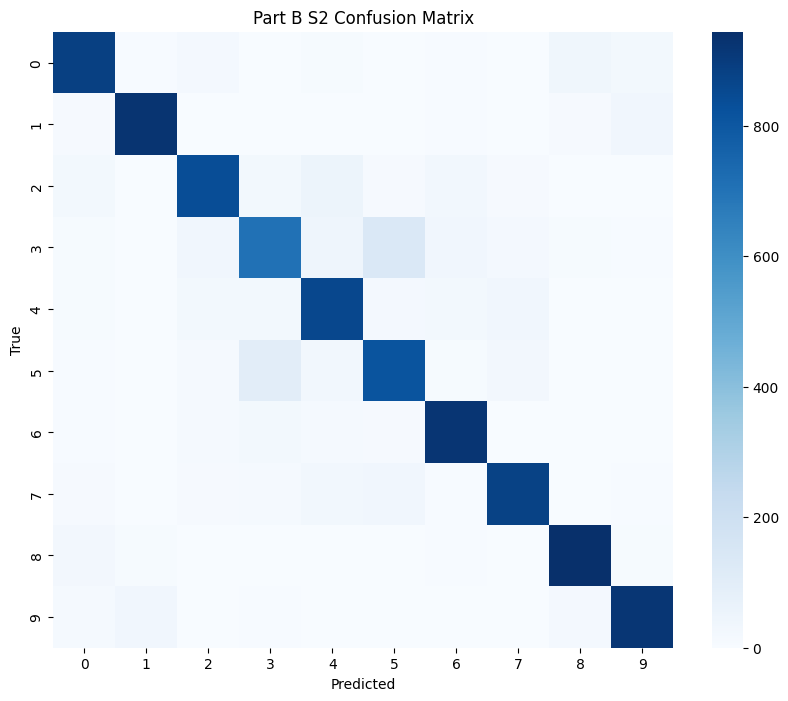


=== Part C: Places365 -> Target vs From Scratch ===
Download finished (check file exists): True

[Part C - Places365] Run 1/3, seed=2326
Places365 load missing keys: 0 unexpected: 0
Epoch 01/20 | train_acc=0.6095 | test_acc=0.6990 | test_f1=0.6973
Epoch 02/20 | train_acc=0.6942 | test_acc=0.7195 | test_f1=0.7175
Epoch 03/20 | train_acc=0.7162 | test_acc=0.7336 | test_f1=0.7331
Epoch 04/20 | train_acc=0.7330 | test_acc=0.7350 | test_f1=0.7337
Epoch 05/20 | train_acc=0.7492 | test_acc=0.7481 | test_f1=0.7481
Epoch 06/20 | train_acc=0.7627 | test_acc=0.7492 | test_f1=0.7482
Epoch 07/20 | train_acc=0.7729 | test_acc=0.7511 | test_f1=0.7501
Epoch 08/20 | train_acc=0.7834 | test_acc=0.7543 | test_f1=0.7536
Epoch 09/20 | train_acc=0.7955 | test_acc=0.7612 | test_f1=0.7607
Epoch 10/20 | train_acc=0.8069 | test_acc=0.7569 | test_f1=0.7578
Epoch 11/20 | train_acc=0.8180 | test_acc=0.7596 | test_f1=0.7597
Epoch 12/20 | train_acc=0.8300 | test_acc=0.7603 | test_f1=0.7611
Epoch 13/20 | train_acc=0

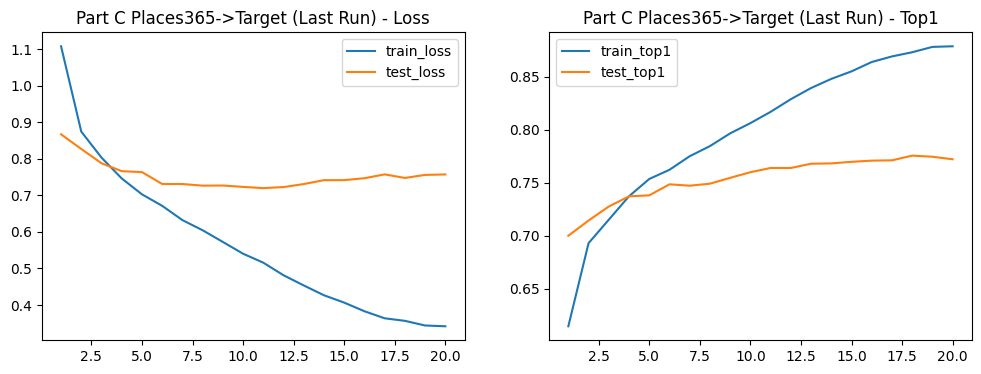

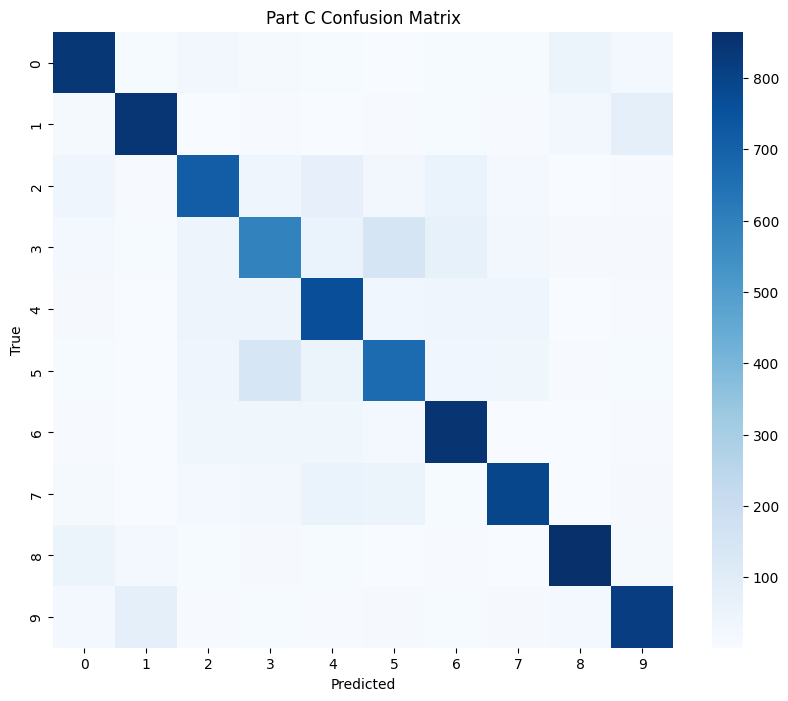


=== Part D: Multi-Stage Transfer on CIFAR10 ===


100%|██████████| 169M/169M [00:13<00:00, 13.0MB/s]



[Part D - Path1] Run 1/3, seed=2426
Epoch 01/15 | train_acc=0.5983 | test_acc=0.7173 | test_f1=0.7161
Epoch 02/15 | train_acc=0.7139 | test_acc=0.7471 | test_f1=0.7462
Epoch 03/15 | train_acc=0.7436 | test_acc=0.7676 | test_f1=0.7656
Epoch 04/15 | train_acc=0.7600 | test_acc=0.7714 | test_f1=0.7707
Epoch 05/15 | train_acc=0.7767 | test_acc=0.7794 | test_f1=0.7782
Epoch 06/15 | train_acc=0.7912 | test_acc=0.7785 | test_f1=0.7776
Epoch 07/15 | train_acc=0.8023 | test_acc=0.7849 | test_f1=0.7842
Epoch 08/15 | train_acc=0.8148 | test_acc=0.7888 | test_f1=0.7885
Epoch 09/15 | train_acc=0.8225 | test_acc=0.7944 | test_f1=0.7941
Epoch 10/15 | train_acc=0.8329 | test_acc=0.7939 | test_f1=0.7940
Epoch 11/15 | train_acc=0.8404 | test_acc=0.7974 | test_f1=0.7972
Epoch 12/15 | train_acc=0.8479 | test_acc=0.7992 | test_f1=0.7989
Epoch 13/15 | train_acc=0.8561 | test_acc=0.8012 | test_f1=0.8008
Epoch 14/15 | train_acc=0.8619 | test_acc=0.8005 | test_f1=0.8006
Epoch 15/15 | train_acc=0.8600 | test_a

In [ ]:
# Main run cell: executes Parts A->D in order and stores outputs
part_a_results = run_part_a(CFG)
part_b_results = run_part_b(CFG)
part_c_results = run_part_c(CFG, part_a_results=part_a_results)
part_d_results = run_part_d(CFG)

In [ ]:
# Summary table cell: prints final mean +- std values for report
def mean_std(x):
    x = np.array(x, dtype=float)
    return float(x.mean()), float(x.std(ddof=1))

summary = {}
summary['Part A Top1'] = mean_std(part_a_results['top1_runs'])
summary['Part B S1 Top1'] = mean_std(part_b_results['strategy1']['top1_runs'])
summary['Part B S2 Top1'] = mean_std(part_b_results['strategy2']['top1_runs'])
summary['Part C Top1'] = mean_std(part_c_results['top1_runs'])
summary['Part D Path1 Top1'] = mean_std(part_d_results['path1_top1'])
summary['Part D Path2 Top1'] = mean_std(part_d_results['path2_top1'])

print('\n=== Final Summary (Top1 mean +- std) ===')
for k, (m, s) in summary.items():
    print(f'{k}: {m:.4f} +- {s:.4f}')


=== Final Summary (Top1 mean +- std) ===
Part A Top1: 0.9023 +- 0.0014
Part B S1 Top1: 0.8067 +- 0.0055
Part B S2 Top1: 0.8669 +- 0.0021
Part C Top1: 0.7707 +- 0.0042
Part D Path1 Top1: 0.8030 +- 0.0027
Part D Path2 Top1: 0.8039 +- 0.0025


## Section 3 - Report Writing Blocks (Paste-ready)

Use these prompts as your final write-up structure inside this notebook. Keep your analysis tied to your exact numbers and plots.

### Part A (From Scratch)
- Model architecture, hyperparameters, and reproducibility settings.
- Top-1 and macro-F1 with mean +- std (3 runs).
- Learning behavior and confusion matrix error patterns.

### Part B (ImageNet -> Target)
- Strategy 1 vs Strategy 2 setup and why this is a fair comparison.
- Performance differences and likely reasons (adaptation depth, overfitting, optimization).
- Which strategy is better under the same budget.

### Part C (Places365 -> Target)
- Explain transfer path and whether it consistently outperforms Part A.
- Include mean +- std and (if available) significance test outcome.
- Interpretation: why scene pretraining helps or does not help on CIFAR10 classes.

### Part D (Multi-Stage Transfer)
- Path 1 vs Path 2 setup per stage (freeze policy, LR, epochs).
- Final CIFAR10 comparison with variance.
- Final conclusion on whether two-stage transfer is worthwhile in this setup.


In [ ]:
# Reproducibility artifact: exports all key results/config to JSON
# Save machine-readable results for appendix/reproducibility
import json
results_out = {
    'config': asdict(CFG),
    'part_a': {'top1_runs': part_a_results['top1_runs'], 'f1_runs': part_a_results['f1_runs']},
    'part_b': {
        'strategy1': {'top1_runs': part_b_results['strategy1']['top1_runs'], 'f1_runs': part_b_results['strategy1']['f1_runs']},
        'strategy2': {'top1_runs': part_b_results['strategy2']['top1_runs'], 'f1_runs': part_b_results['strategy2']['f1_runs']},
    },
    'part_c': {'top1_runs': part_c_results['top1_runs'], 'f1_runs': part_c_results['f1_runs']},
    'part_d': {
        'path1_top1': part_d_results['path1_top1'], 'path1_f1': part_d_results['path1_f1'],
        'path2_top1': part_d_results['path2_top1'], 'path2_f1': part_d_results['path2_f1'],
    },
}
with open('assignment2_results.json', 'w') as f:
    json.dump(results_out, f, indent=2)
print('Wrote assignment2_results.json')

Wrote assignment2_results.json
